# MuSiQue-Ans exploratory data analysis

This notebook examines the validated MuSiQue-Ans train and development splits. It uses the reusable loader rather than re-parsing JSONL, and it does not perform retrieval or answer generation.

**Hop definition:** the number of gold `question_decomposition` steps. MuSiQue-Ans should therefore contain only 2-, 3-, and 4-hop questions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.musique_loader import load_split, read_jsonl, split_path, supporting_paragraphs, validate_records

sns.set_theme(style='whitegrid', context='notebook')
# Keep anomalies visible: strict validation is reported below; no records are repaired or dropped for EDA.
train_records = load_split('train', validate=False)
dev_records = load_split('dev', validate=False)
records_by_split = {'train': train_records, 'dev': dev_records}
print(f'Loaded {len(train_records):,} train and {len(dev_records):,} development examples.')

Loaded 19,938 train and 2,417 development examples.


## 1. Does the local release pass its schema checks and have the expected scale?

The strict validator runs before the descriptive analysis. Any reported anomalies remain in the original data and in all following summaries. The table and chart then verify split sizes and compare reasoning-depth distributions.

train: 42 strict validation issue(s)
paragraph_count                   21
inconsistent_paragraph_indices    21
dev: 32 strict validation issue(s)
paragraph_count                   16
inconsistent_paragraph_indices    16


,split,hop_count,questions,percentage
0,dev,2,1252,51.799752
1,dev,3,760,31.443939
2,dev,4,405,16.756309
3,train,2,14376,72.103521
4,train,3,4387,22.003210
5,train,4,1175,5.893269


,questions
split,
dev,2417
train,19938


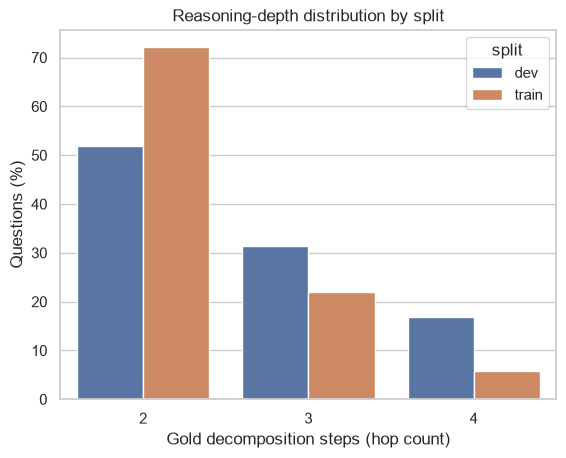

In [ ]:
for split in ('train', 'dev'):
    validation = validate_records(read_jsonl(split_path(split)), split=split)
    print(f'{split}: {len(validation.issues)} strict validation issue(s)')
    print(pd.Series(issue.code for issue in validation.issues).value_counts().to_string() if validation.issues else 'PASS') #type: ignore

example_rows = [
    {'split': split, 'hop_count': record.hop_count}
    for split, records in records_by_split.items()
    for record in records
]
examples = pd.DataFrame(example_rows)
hop_summary = (examples.groupby(['split', 'hop_count']).size().rename('questions').reset_index())
hop_summary['percentage'] = hop_summary.groupby('split')['questions'].transform(lambda values: 100 * values / values.sum())
display(hop_summary)
display(examples.groupby('split').size().rename('questions').to_frame())
sns.barplot(data=hop_summary, x='hop_count', y='percentage', hue='split')
plt.title('Reasoning-depth distribution by split')
plt.xlabel('Gold decomposition steps (hop count)')
plt.ylabel('Questions (%)')
plt.show()

## 2. How much of each 20-paragraph context is evidence?

Supporting paragraphs are the gold evidence labels available for evaluating later retrieval work. Comparing their count with hop count reveals whether every reasoning step maps to distinct evidence.

count  mean  std  min   5%  50%  95%  max
split hop_count                                             
dev   2           1252.0   2.0  0.0  2.0  2.0  2.0  2.0  2.0
      3            760.0   3.0  0.0  3.0  3.0  3.0  3.0  3.0
      4            405.0   4.0  0.0  4.0  4.0  4.0  4.0  4.0
train 2          14376.0   2.0  0.0  2.0  2.0  2.0  2.0  2.0
      3           4387.0   3.0  0.0  3.0  3.0  3.0  3.0  3.0
      4           1175.0   4.0  0.0  4.0  4.0  4.0  4.0  4.0

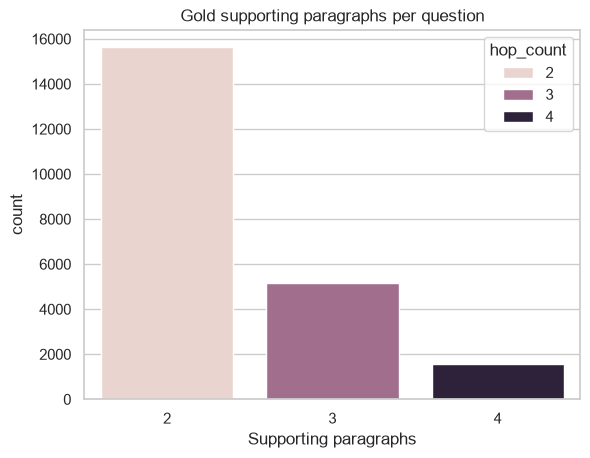

In [3]:
support_rows = [
    {'split': split, 'hop_count': record.hop_count, 'supporting_paragraphs': len(supporting_paragraphs(record))}
    for split, records in records_by_split.items()
    for record in records
]
support_df = pd.DataFrame(support_rows)
display(support_df.groupby(['split', 'hop_count'])['supporting_paragraphs'].describe(percentiles=[.05, .5, .95]))
sns.countplot(data=support_df, x='supporting_paragraphs', hue='hop_count')
plt.title('Gold supporting paragraphs per question')
plt.xlabel('Supporting paragraphs')
plt.show()

## 3. How large are individual paragraphs and full contexts?

We use whitespace-delimited word counts, which are transparent and tokenizer-independent. They are useful for comparing examples, but are not interchangeable with model-specific token counts. Full context means the question plus all 20 paragraph texts.


Paragraph words


,count,mean,std,min,5%,25%,50%,75%,95%,max
split,,,,,,,,,,
dev,48315.0,82.65578,49.908105,20.0,25.0,45.0,72.0,106.0,182.0,299.0
train,398724.0,79.00245,46.788911,19.0,25.0,44.0,68.0,102.0,171.0,299.0



Full-context words


,count,mean,std,min,5%,25%,50%,75%,95%,max
split,,,,,,,,,,
dev,2417.0,1670.366570,410.433603,564.0,1064.0,1391.0,1636.0,1911.0,2451.6,3235.0
train,19938.0,1595.867941,379.105449,569.0,1034.0,1319.0,1567.0,1842.0,2262.0,3356.0


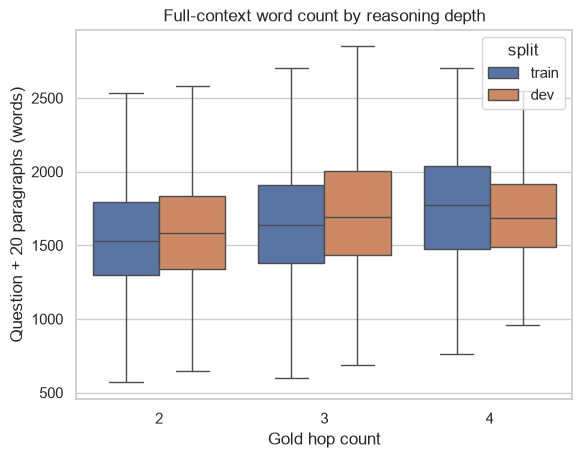

In [4]:
paragraph_rows, context_rows = [], []
for split, records in records_by_split.items():
    for record in records:
        context_words = len(record.question.split()) + sum(len(p.paragraph_text.split()) for p in record.paragraphs)
        context_rows.append({'split': split, 'hop_count': record.hop_count, 'context_words': context_words})
        paragraph_rows.extend({'split': split, 'hop_count': record.hop_count, 'is_supporting': p.is_supporting, 'paragraph_words': len(p.paragraph_text.split())} for p in record.paragraphs)

paragraph_df = pd.DataFrame(paragraph_rows)
context_df = pd.DataFrame(context_rows)
for label, frame, column in [('Paragraph words', paragraph_df, 'paragraph_words'), ('Full-context words', context_df, 'context_words')]:
    print(f'\n{label}')
    display(frame.groupby('split')[column].describe(percentiles=[.05, .25, .5, .75, .95]))

sns.boxplot(data=context_df, x='hop_count', y='context_words', hue='split', showfliers=False)
plt.title('Full-context word count by reasoning depth')
plt.xlabel('Gold hop count')
plt.ylabel('Question + 20 paragraphs (words)')
plt.show()

## 4. Are distractor titles related to gold evidence elsewhere?

A distractor is non-supporting within its own question. This analysis tests a narrow, evidence-based signal of cross-question ambiguity: whether a distractor title occurs as a supporting title for another example in the same split. It does not claim semantic hardness beyond this title-level overlap.

In [5]:
distractor_rows = []
for split, records in records_by_split.items():
    supporting_titles = {p.title for record in records for p in record.paragraphs if p.is_supporting}
    for record in records:
        distractors = [p for p in record.paragraphs if not p.is_supporting]
        overlap = sum(p.title in supporting_titles for p in distractors)
        distractor_rows.append({'split': split, 'hop_count': record.hop_count, 'distractors': len(distractors), 'overlapping_titles': overlap, 'has_overlap': overlap > 0})

distractor_df = pd.DataFrame(distractor_rows)
distractor_summary = distractor_df.groupby(['split', 'hop_count']).agg(questions=('has_overlap', 'size'), questions_with_overlap=('has_overlap', 'mean'), mean_overlapping_titles=('overlapping_titles', 'mean'))
distractor_summary['questions_with_overlap'] *= 100
display(distractor_summary.rename(columns={'questions_with_overlap': 'questions_with_overlap_pct'}))

questions  questions_with_overlap_pct  \
split hop_count                                          
dev   2               1252                   73.003195   
      3                760                   82.368421   
      4                405                   82.469136   
train 2              14376                   87.743461   
      3               4387                   91.338044   
      4               1175                   91.744681   

                 mean_overlapping_titles  
split hop_count                           
dev   2                         2.257987  
      3                         2.907895  
      4                         2.602469  
train 2                         3.398929  
      3                         4.156827  
      4                         4.478298

## 5. Are there missing or abnormal values worth flagging?

The loader has already enforced required fields, 20 paragraphs, valid references, and valid hop structure. The checks below surface unusually short or long paragraph lengths and duplicate titles within a context for manual inspection rather than silently removing anything.

In [6]:
length_limits = paragraph_df['paragraph_words'].quantile([.01, .99])
print('Paragraph word-count 1st/99th percentiles:', length_limits.to_dict())
print('Empty paragraph texts:', (paragraph_df['paragraph_words'] == 0).sum())
duplicate_title_rows = []
for split, records in records_by_split.items():
    for record in records:
        titles = [paragraph.title for paragraph in record.paragraphs]
        duplicate_title_rows.append({'split': split, 'question_id': record.id, 'duplicate_titles': len(titles) - len(set(titles))})
duplicate_titles = pd.DataFrame(duplicate_title_rows)
display(duplicate_titles.groupby('split')['duplicate_titles'].describe())

Paragraph word-count 1st/99th percentiles: {0.01: 21.0, 0.99: 238.0}
Empty paragraph texts: 0


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,2417.0,1.505585,2.354383,0.0,0.0,1.0,2.0,16.0
train,19938.0,1.397783,2.372454,0.0,0.0,0.0,2.0,18.0


## Conclusions

The exploratory analysis establishes the main characteristics of the validated MuSiQue-Ans data used in this project:

- The train and development splits contain 2-, 3-, and 4-hop questions, providing multiple levels of reasoning difficulty for evaluation.
- Each example contains around 20 paragraphs, so the full-context word-count distribution provides a practical estimate of the context budget required by downstream models.
- The number of gold supporting paragraphs gives a direct retrieval target. Retrieval performance should therefore be evaluated by evidence recall as well as final answer accuracy.
- Paragraph-length and full-context summaries highlight the expected input-size variation across examples and reasoning depths.
- Distractor-title overlap reveals a measurable source of ambiguity, but it should not be interpreted as a complete measure of semantic difficulty.
- Short, long, empty, or duplicate-title cases are flagged for inspection rather than silently removed, preserving reproducibility and avoiding unintended changes to the dataset.

Overall, these findings motivate an adaptive retrieval system that prioritizes complete coverage of the gold evidence while controlling the amount of irrelevant context passed to the answer-generation component.